# 시계열 피처 선택 — 상관계수 희석 진단

이 노트북의 목적은 하나다: **소표본을 전체로 합쳐서 보면 요일별 연속성 차이 때문에 상관계수가 희석된다**는 것을 실제 데이터로 보여주는 것. 화요일 단독 모델을 스텝와이즈로 쌓아가는 과정(모델 구축)은 별도 노트북 (`03_tuesday_solo_model.ipynb`)에서 다룬다.


In [1]:
# ── 기본 ──
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 시각화 ──
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import subprocess
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('폰트 적용:', plt.rcParams['font.family'])


# ── 인코딩 ──
from sklearn.preprocessing import OneHotEncoder

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print("✅ 라이브러리 로드 완료")


폰트 적용: ['NanumGothic']
✅ 라이브러리 로드 완료


## 데이터 준비


In [2]:
data = pd.read_csv('/content/time_table.csv')

feature_cols = [
    'date', 'day_of_week', 'sum_g', 'cumul_16_19', 'cumul_20_22',
    'lag_prev_day_t1', 'lag_same_day_t1', 'lag_prev_day_t2', 'lag_same_day_t2',
    'lag_biweekly_t1', 'lag_biweekly_t2',
    'roll_prev_3days_mean_t1', 'roll_same_3days_mean_t1',
    'roll_prev_3days_mean_t2', 'roll_same_3days_mean_t2',
    'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2',
    'lag_prev_t1_ratio', 'lag_same_t1_ratio', 'lag_prev_t2_ratio', 'lag_same_t2_ratio',
    'prev_sum_g', 'same_prev_sum_g',
]

data_v1 = data.copy().drop(columns=['dcl_id'])[feature_cols]
data_v1.head()


,date,day_of_week,sum_g,cumul_16_19,cumul_20_22,lag_prev_day_t1,lag_same_day_t1,lag_prev_day_t2,lag_same_day_t2,lag_biweekly_t1,...,roll_prev_3days_mean_t2,roll_same_3days_mean_t2,roll_prev_5days_mean_t1,roll_prev_5days_mean_t2,lag_prev_t1_ratio,lag_same_t1_ratio,lag_prev_t2_ratio,lag_same_t2_ratio,prev_sum_g,same_prev_sum_g
0,2026-05-11,월,20650,11550,9100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-12,화,28300,16600,11700,11550.0,NaN,9100.0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.56,NaN,0.44,NaN,20650.0,NaN
2,2026-05-15,금,23450,12300,11150,16600.0,NaN,11700.0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.59,NaN,0.41,NaN,28300.0,NaN
3,2026-05-18,월,29500,12600,16900,12300.0,11550.0,11150.0,9100.0,NaN,...,10650.0,NaN,NaN,NaN,0.52,0.56,0.48,0.44,23450.0,20650.0
4,2026-05-19,화,16150,9200,6950,12600.0,16600.0,16900.0,11700.0,NaN,...,13250.0,NaN,NaN,NaN,0.43,0.59,0.57,0.41,29500.0,28300.0


## 요일 원-핫 인코딩


In [3]:
encoder = OneHotEncoder(drop=['월'], sparse_output=False)  # 월요일을 기준(baseline)으로
encoded = encoder.fit_transform(data_v1[['day_of_week']])
encoded_cols = encoder.get_feature_names_out(['day_of_week'])
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=data_v1.index)

data_scatter = data_v1.drop(columns=['day_of_week'])
data_scatter = pd.concat([data_scatter, encoded_df], axis=1)
data_scatter.head()


,date,sum_g,cumul_16_19,cumul_20_22,lag_prev_day_t1,lag_same_day_t1,lag_prev_day_t2,lag_same_day_t2,lag_biweekly_t1,lag_biweekly_t2,...,roll_prev_5days_mean_t1,roll_prev_5days_mean_t2,lag_prev_t1_ratio,lag_same_t1_ratio,lag_prev_t2_ratio,lag_same_t2_ratio,prev_sum_g,same_prev_sum_g,day_of_week_금,day_of_week_화
0,2026-05-11,20650,11550,9100,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2026-05-12,28300,16600,11700,11550.0,NaN,9100.0,NaN,NaN,NaN,...,NaN,NaN,0.56,NaN,0.44,NaN,20650.0,NaN,0.0,1.0
2,2026-05-15,23450,12300,11150,16600.0,NaN,11700.0,NaN,NaN,NaN,...,NaN,NaN,0.59,NaN,0.41,NaN,28300.0,NaN,1.0,0.0
3,2026-05-18,29500,12600,16900,12300.0,11550.0,11150.0,9100.0,NaN,NaN,...,NaN,NaN,0.52,0.56,0.48,0.44,23450.0,20650.0,0.0,0.0
4,2026-05-19,16150,9200,6950,12600.0,16600.0,16900.0,11700.0,NaN,NaN,...,NaN,NaN,0.43,0.59,0.57,0.41,29500.0,28300.0,0.0,1.0


## 분석에 쓸 시계열 피처 목록

화요일·월+금 상관계수를 각각 볼 때 반복해서 쓰이므로 한 번만 정의해둔다.


In [4]:
time_cols = [
    'cumul_16_19', 'cumul_20_22',
    'lag_prev_day_t1', 'lag_same_day_t1', 'lag_prev_day_t2', 'lag_same_day_t2',
    'lag_biweekly_t1', 'lag_biweekly_t2',
    'roll_prev_3days_mean_t1', 'roll_same_3days_mean_t1',
    'roll_prev_3days_mean_t2', 'roll_same_3days_mean_t2',
    'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2',
    'lag_prev_t1_ratio', 'lag_same_t1_ratio', 'lag_prev_t2_ratio', 'lag_same_t2_ratio',
    'prev_sum_g', 'same_prev_sum_g',
]


---
## 1. 전체 데이터 상관관계 히트맵 (연속·비연속 요일 혼합)


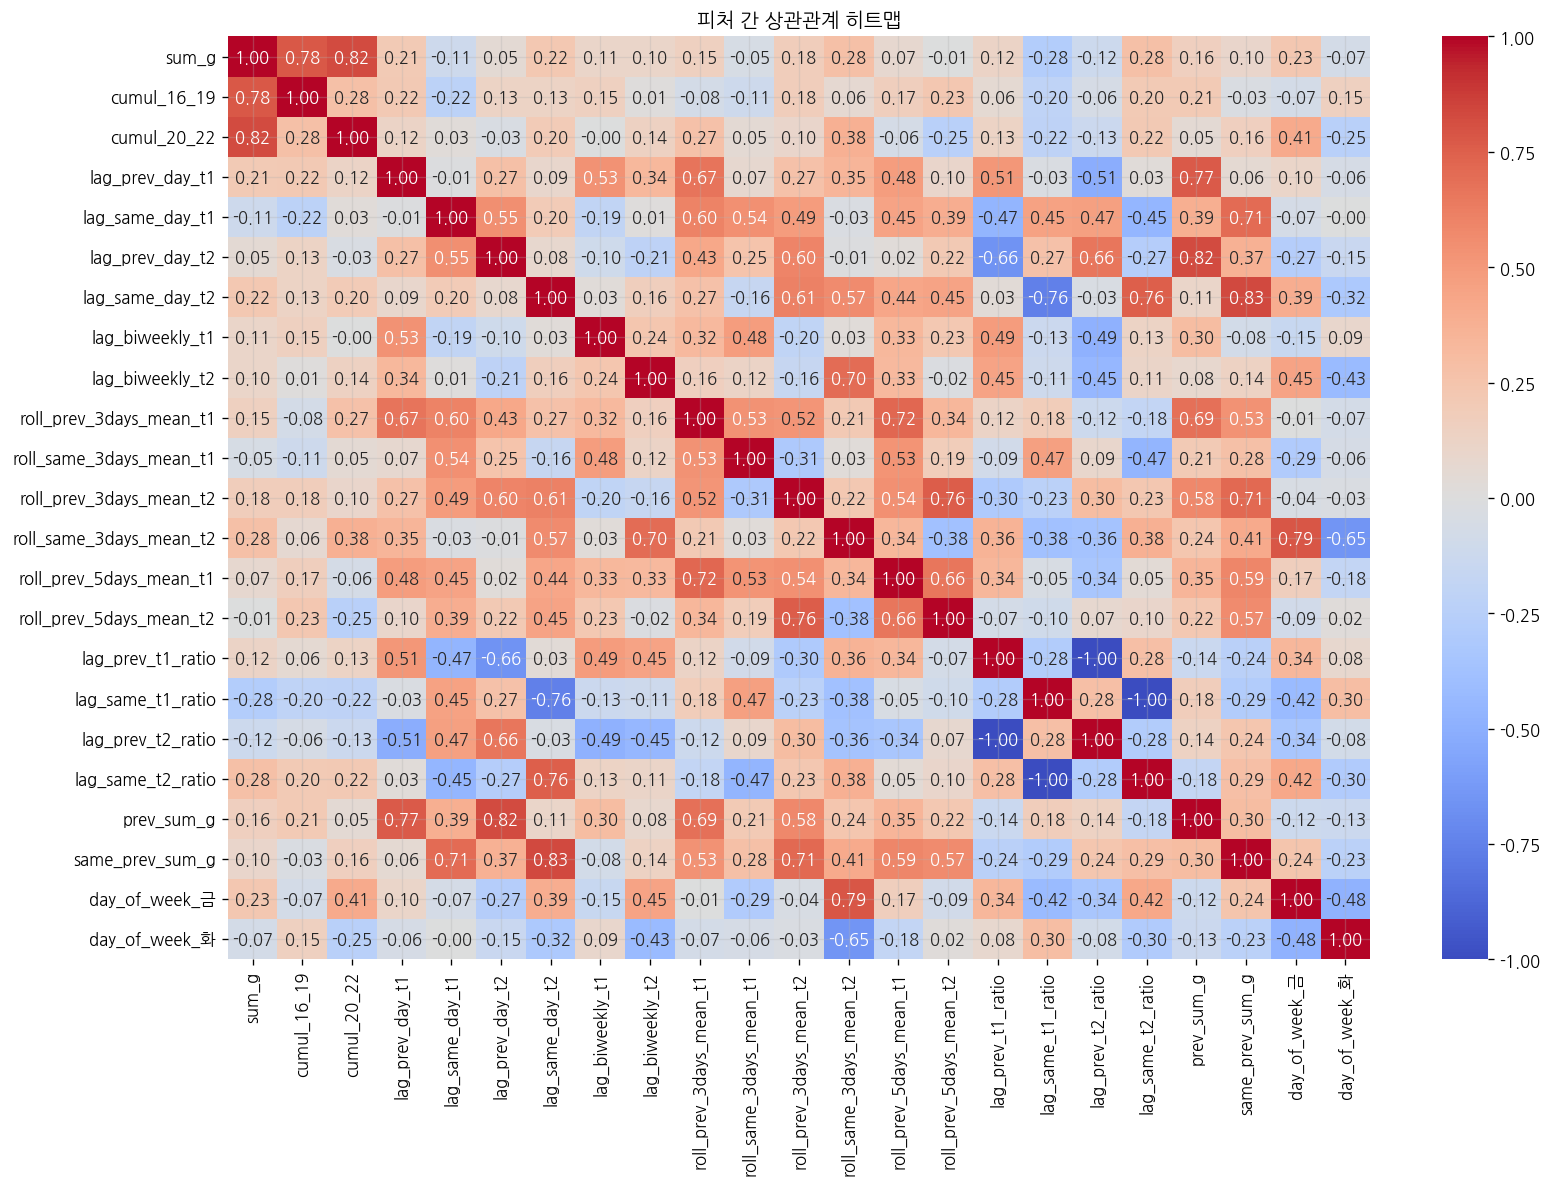

In [5]:
import seaborn as sns

# 수치형 컬럼만 선택
numeric_cols = data_scatter.select_dtypes(include='number').drop(columns=['date'], errors='ignore')

# 상관관계 히트맵
plt.figure(figsize=(14, 10))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,       # 숫자 표시
    fmt='.2f',        # 소수점 2자리
    cmap='coolwarm',  # 색상 (파랑=음의상관, 빨강=양의상관)
    center=0
)
plt.title('피처 간 상관관계 히트맵')
plt.tight_layout()
plt.show()

## 타겟: cumul_16_19

전체 데이터셋은 소표본인 데다, 요일별로 연속성이 다른 표본(화요일=1일 텀 / 월·금=3일 텀)이 섞여 있어 상관계수가 희석된다. 그래서 연속성 유형별(화요일 vs 월+금)로 나눠서 다시 확인한다.


---
## 2. 화요일(연속 근무일)만 필터링한 상관계수


In [6]:
tue_data = data_scatter[data_scatter['day_of_week_화'] == 1]
tue_data = tue_data[~tue_data['date'].isin(['2026-06-29', '2026-06-30'])]  # 이상치 제외

print(f"화요일 데이터 수: {len(tue_data)}행")
print()
print("【화요일 cumul_16_19 상관계수】")
print(tue_data[time_cols].corr()['cumul_16_19'].sort_values(ascending=False))
print()
print("【화요일 cumul_20_22 상관계수】")
print(tue_data[time_cols].corr()['cumul_20_22'].sort_values(ascending=False))


화요일 데이터 수: 7행

【화요일 cumul_16_19 상관계수】
cumul_16_19                1.000000
roll_prev_5days_mean_t1    0.565282
lag_prev_day_t1            0.459259
cumul_20_22                0.393298
lag_same_t1_ratio          0.348401
roll_prev_3days_mean_t1    0.320430
roll_same_3days_mean_t2    0.318489
prev_sum_g                 0.303387
roll_prev_3days_mean_t2    0.192024
roll_prev_5days_mean_t2    0.152648
lag_prev_t1_ratio          0.133247
lag_prev_day_t2            0.079159
lag_prev_t2_ratio         -0.133247
lag_biweekly_t2           -0.143917
lag_same_day_t1           -0.159486
same_prev_sum_g           -0.225987
lag_same_day_t2           -0.269989
lag_same_t2_ratio         -0.348401
lag_biweekly_t1           -0.579342
roll_same_3days_mean_t1   -0.755017
Name: cumul_16_19, dtype: float64

【화요일 cumul_20_22 상관계수】
cumul_20_22                1.000000
lag_same_t2_ratio          0.444526
cumul_16_19                0.393298
lag_biweekly_t1            0.374505
prev_sum_g                 0.227427
lag_

### 화요일 T1(16_19) 유효 값 (절댓값 0.3 이상)
1. roll_prev_5days_mean_t1  0.565  (spurious 주의)
2. lag_biweekly_t1         -0.579  (격주 오후)
3. lag_prev_day_t1          0.459  (직전 영업일 오후)
4. lag_same_t1_ratio        0.348  (동요일 직전 오후 비중)
5. lag_same_t2_ratio       -0.348  (동요일 직전 저녁 비중)
6. roll_prev_3days_mean_t1  0.320
7. roll_same_3days_mean_t2  0.318  (spurious 주의)
8. prev_sum_g               0.303  (직전 영업일 전체 수요)
9. roll_same_3days_mean_t1 -0.755  (spurious 주의)


---
## 3. 월+금(비연속 근무일) 상관계수 — 이상치 포함/미포함 비교


In [7]:
# 월+금 묶어서 확인 (화요일 제외)
monfri_data = data_scatter[data_scatter['day_of_week_화'] == 0]
monfri_data_v2= monfri_data[~monfri_data['date'].isin(['2026-06-29', '2026-06-30'])]

print(f"월+금 데이터 수: {len(monfri_data)}행")
print()
print("【월+금 cumul_16_19 이상치 포함 상관계수】")
print(monfri_data[time_cols].corr()['cumul_16_19'].sort_values(ascending=False))

print(f"월+금 데이터 수: {len(monfri_data_v2)}행")
print()
print("【월+금 cumul_16_19 이상치 미포함 상관계수】")
print(monfri_data_v2[time_cols].corr()['cumul_16_19'].sort_values(ascending=False))


print("【월+금 cumul_20_22 이상치 포함 상관계수】")
print(monfri_data[time_cols].corr()['cumul_20_22'].sort_values(ascending=False))

print("【월+금 cumul_20_22 이상치 미포함 상관계수】")
print(monfri_data_v2[time_cols].corr()['cumul_20_22'].sort_values(ascending=False))

월+금 데이터 수: 15행

【월+금 cumul_16_19 이상치 포함 상관계수】
cumul_16_19                1.000000
lag_biweekly_t1            0.652480
prev_sum_g                 0.371100
roll_same_3days_mean_t2    0.342896
lag_prev_day_t1            0.298799
cumul_20_22                0.291508
roll_prev_5days_mean_t2    0.291021
lag_prev_day_t2            0.282662
lag_same_t2_ratio          0.278567
lag_same_day_t2            0.218492
roll_prev_5days_mean_t1    0.211662
roll_prev_3days_mean_t2    0.196137
lag_biweekly_t2            0.186105
roll_same_3days_mean_t1    0.126267
same_prev_sum_g            0.071455
lag_prev_t1_ratio          0.046496
roll_prev_3days_mean_t1   -0.035324
lag_prev_t2_ratio         -0.046496
lag_same_day_t1           -0.193731
lag_same_t1_ratio         -0.278567
Name: cumul_16_19, dtype: float64
월+금 데이터 수: 14행

【월+금 cumul_16_19 이상치 미포함 상관계수】
cumul_16_19                1.000000
lag_prev_day_t2            0.440530
lag_biweekly_t1            0.411540
prev_sum_g                 0.396358
roll_prev

---
## 종합 — 희석 vs 불안정의 트레이드오프

- **전체 통합**: 표본은 충분하지만(23행), 화요일(1일 텀)과 월+금(3일 텀)의 서로 다른 패턴이 섞여 상관계수가 희석된다.
- **요일별 분리**: 상관계수 강도 자체는 살아나지만(화요일 최대 0.46~0.58), 표본이 7~15행으로 줄어들고 이상치 1개 추가만으로도 값이 크게 흔들린다(월+금 상관계수 비교 참고).

→ 이 트레이드오프가 실제로 신뢰할 수 없는 수준인지, 다음 노트북(`03_tuesday_solo_model.ipynb`)에서 화요일 단독 스텝와이즈 OLS 모델을 직접 쌓아보며 검증한다.
